# Produce expected neutrino map for a given source population model

In [6]:
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# --- notebook cell example ---
import numpy as np, matplotlib.pyplot as plt, healpy as hp
from icecube_population_project.nu_pop_core import CosmologyGrid, SpectrumParams, PopulationParams, fz_sfr_md14
from icecube_population_project.IceCube_expected_nu_counts import MapMakerConfig, make_expected_counts_maps


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Finite per-source µ? True
Total expected per bin: [115.56434689  43.01092991  11.98281893]
Total sources to zmax (full sky): 11818436.250394974
One-source check (integrated bin): 5.376755743404585e-07


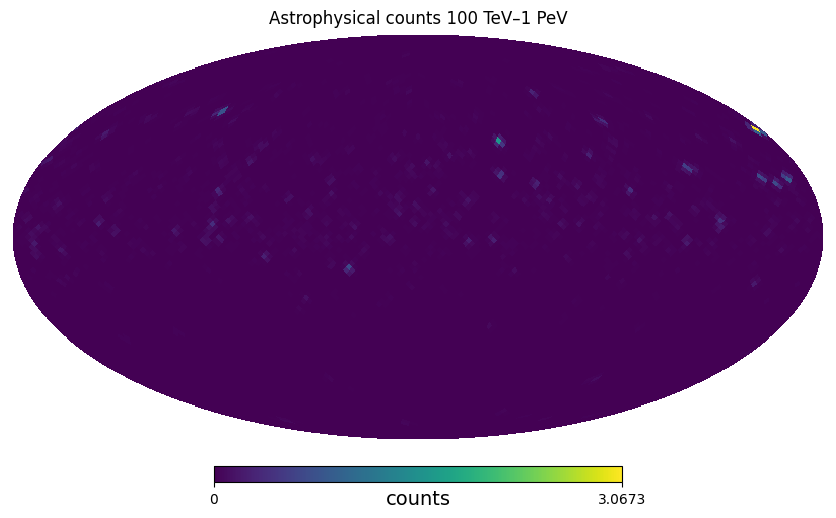

In [ ]:

cosmo = CosmologyGrid(zmax=6.0, nz=4000)
spec  = SpectrumParams(gamma=2.0, Emin=1e5, Emax=1e8, L=1e42)   # L in erg/s (converted internally)
pop   = PopulationParams(n0=1e-6, fz_fn=fz_sfr_md14)

cfg = MapMakerConfig(dataset="20210126", period="IC86_II",
                     aeff_units="m2",   # switch to "cm2" if your EffectiveArea is already cm^2
                     time_years=7.5, nside=32,
                     psf_mode="fixed", psf_sigma_deg=1.0,
                     sources_to_draw=5000,
                     scale_to_full_population=True,
                     energy_bin_edges_GeV=np.array([1e5,1e6,1e7,1e8]))

out = make_expected_counts_maps(spec, pop, cosmo, cfg)
print("Finite per-source µ?", np.isfinite(out["mu_per_bin"]).all())
print("Total expected per bin:", out["total_expected_per_bin"])
print("Total sources to zmax (full sky):", out["N_src_tot"])
print("One-source check (integrated bin):", out["mu_check_one_source"])

hp.mollview(out["maps"][0], title="Astrophysical counts 100 TeV-1 PeV", unit="counts"); plt.show()



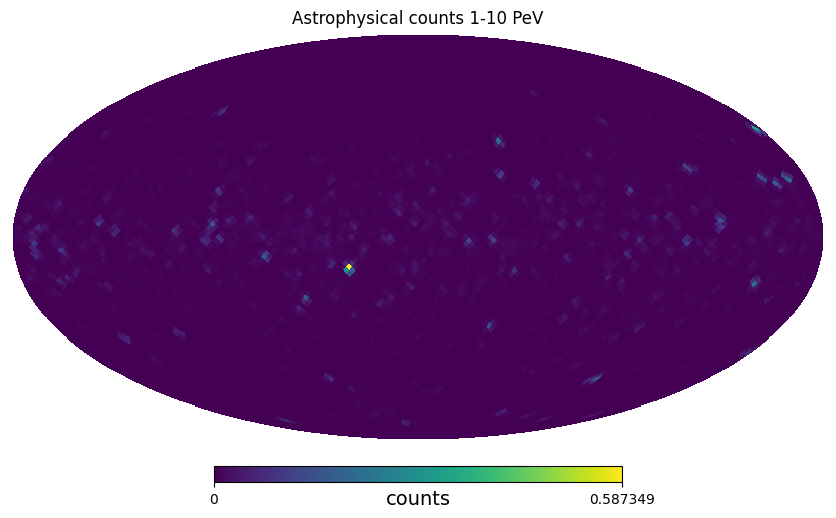

In [8]:
hp.mollview(out["maps"][1], title="Astrophysical counts 1-10 PeV", unit="counts"); plt.show()



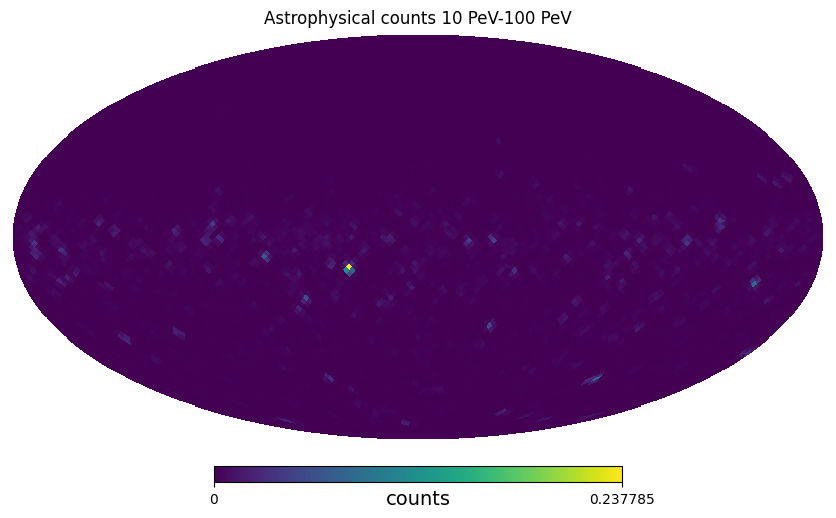

In [9]:
hp.mollview(out["maps"][2], title="Astrophysical counts 10 PeV-100 PeV", unit="counts"); plt.show()

